# IC50 + Boltz2 Token Usage and Cost Analysis

Reconstructs LLM prompts for IC50 MPro QED and Boltz2 MGYP optimization runs, estimates token usage across modes, and computes costs including final summary calls.

In [7]:
import hashlib
import json
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any

from anthropic import Anthropic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)
plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "axes.labelsize": 13,
    "axes.titlesize": 14, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 11, "figure.figsize": (7, 4), "axes.linewidth": 1.2,
    "grid.linewidth": 0.6, "lines.linewidth": 2.2,
})

ROOT = Path("../../").resolve()
RESULTS_DIR_IC50 = ROOT / "data" / "results" / "ic50mpro_qed"
RUNS_DIR = ROOT / "data" / "runs"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "claude-opus-4-5"
MAX_ITERATIONS_FOR_COST = 50
CONTEXT_WINDOW_LIMIT = 200_000
PROMPT_PRICE_PER_M = 5.0
COMPLETION_PRICE_PER_M = 25.0

# IC50 modes
IC50_MODE_SPECS = [("Full XAI", "claude-opus-4.5_full_xai"), ("Partial XAI", "claude-opus-4.5_partial_xai"), ("No XAI", "claude-opus-4.5_no_xai"), ("No Description", "claude-opus-4.5_no_description")]
IC50_MODE_COLORS = {"Full XAI": "#2E86AB", "Partial XAI": "#00a69d", "No XAI": "#ffcc00", "No Description": "#f58220"}

# Boltz2 MGYP modes (from analysis/paper/boltz2.py)
BOLTZ2_MGYP_TRACES = [
    ("boltz2_binding_optimization_conversation_20260120_185114.json", "With Explanation", 1),
    ("boltz2_binding_optimization_conversation_20260120_164334.json", "No Explanation", 1),
    ("boltz2_binding_optimization_conversation_20260121_125157.json", "No Protein", 1),
    ("boltz2_binding_optimization_conversation_20260121_125339.json", "With Explanation", 2),
    ("boltz2_binding_optimization_conversation_20260121_130409.json", "No Explanation", 2),
    ("boltz2_binding_optimization_conversation_20260121_130058.json", "No Protein", 2),
    ("boltz2_binding_optimization_conversation_20260121_152419.json", "With Explanation", 3),
    ("boltz2_binding_optimization_conversation_20260121_153547.json", "No Explanation", 3),
    ("boltz2_binding_optimization_conversation_20260121_152832.json", "No Protein", 3),
]
BOLTZ2_MODE_COLORS = {"With Explanation": "#2E86AB", "No Explanation": "#ffcc00", "No Protein": "#f58220"}

# Load .env and explicitly prefer Anthropic vars from .env to avoid stale shell values.
ENV_PATH = ROOT / ".env"
env_values: dict[str, str] = {}
if ENV_PATH.exists():
    for raw_line in ENV_PATH.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        env_values[key.strip()] = value.strip().strip('"').strip("'")

# Keep legacy behavior for non-sensitive vars.
for key, value in env_values.items():
    os.environ.setdefault(key, value)

# Override Anthropic vars from .env when present.
if "ANTHROPIC_API_KEY" in env_values:
    os.environ["ANTHROPIC_API_KEY"] = env_values["ANTHROPIC_API_KEY"]
if "ANTHROPIC_BASE_URL" in env_values:
    os.environ["ANTHROPIC_BASE_URL"] = env_values["ANTHROPIC_BASE_URL"]

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY")
ANTHROPIC_BASE_URL = os.environ.get("ANTHROPIC_BASE_URL", "https://api.anthropic.com")

masked_key = "<missing>"
if ANTHROPIC_API_KEY:
    masked_key = f"{ANTHROPIC_API_KEY[:12]}... (len={len(ANTHROPIC_API_KEY)})"

print(f"Root: {ROOT}")
print(f"Using Anthropic API: {bool(ANTHROPIC_API_KEY)}")
print(f"Anthropic base URL: {ANTHROPIC_BASE_URL}")
print(f"Anthropic key: {masked_key}")

Root: /Users/ahunklinger/Coding/molecule-optimization-agent
Using Anthropic API: True
Anthropic base URL: https://api.anthropic.com
Anthropic key: 88wVasSmKO4P... (len=84)


In [8]:
@dataclass
class TokenCounter:
    model: str
    api_key: str | None = None
    base_url: str = "https://api.anthropic.com"

    def __post_init__(self) -> None:
        self.cache = {}
        self.client = None
        self.backend = "offline_approximation"
        self._encoding = None
        if self.api_key:
            try:
                self.client = Anthropic(api_key=self.api_key, base_url=self.base_url)
                self.backend = "anthropic_sdk"
            except Exception as e:
                print(f"Warning: Failed to initialize client ({e}); using offline.")
        try:
            import tiktoken
            self._encoding = tiktoken.get_encoding("cl100k_base")
        except Exception:
            self._encoding = None

    @staticmethod
    def _payload_hash(payload: dict) -> str:
        payload_str = json.dumps(payload, sort_keys=True, ensure_ascii=False)
        return hashlib.sha256(payload_str.encode("utf-8")).hexdigest()

    def _count_via_anthropic_sdk(self, system: str, messages: list[dict]) -> int:
        try:
            return self.client.messages.count_tokens(model=self.model, system=system, messages=messages).input_tokens
        except Exception as e:
            print(f"Warning: Count API failed ({e}); falling back to offline.")
            self.client = None
            self.backend = "offline_approximation"
            return self._count_text_offline(system, messages)

    def _count_text_offline(self, system: str, messages: list[dict]) -> int:
        blob = "SYSTEM:\n" + system + "\n" + "\n".join(f"{m['role']}:\n{m['content']}" for m in messages)
        if self._encoding is not None:
            return len(self._encoding.encode(blob))
        return max(1, int(round(len(blob) / 4.0)))

    def count_prompt(self, system: str, messages: list[dict]) -> int:
        payload = {"model": self.model, "system": system, "messages": messages}
        key = self._payload_hash(payload)
        if key in self.cache:
            return self.cache[key]
        value = self._count_via_anthropic_sdk(system, messages) if self.client else self._count_text_offline(system, messages)
        self.cache[key] = value
        return value

    def estimate_text_tokens(self, text: str) -> int:
        if self._encoding is not None:
            return len(self._encoding.encode(text))
        return max(1, int(round(len(text) / 4.0)))

counter = TokenCounter(model=MODEL_NAME, api_key=ANTHROPIC_API_KEY, base_url=ANTHROPIC_BASE_URL)
print(f"Token backend: {counter.backend}")

Token backend: anthropic_sdk


In [9]:
QED_THRESHOLD = 0.6
QED_PENALTY_IC50 = 1_000_000


def map_role(role_name: str) -> str | None:
    return {"HumanMessage": "user", "AIMessage": "assistant"}.get(role_name)


def extract_replicate(filename: str) -> int:
    match = re.search(r"rep(\d+)", filename)
    return int(match.group(1)) if match else -1


def safe_float(value: Any, default: float = np.nan) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def build_summary_prompt(conversation: list[dict], trace: list[dict], xai_mode: str | None = None) -> str:
    objective_context = conversation[1]["content"] if len(conversation) > 1 else ""
    keys_to_exclude = {"explanation", "original_score"}
    if xai_mode == "no_description":
        keys_to_exclude.add("scores")
    trace_for_summary = [{k: v for k, v in entry.items() if k not in keys_to_exclude} for entry in trace]
    return f"""You are given the objective and trace of a molecular optimization loop.

Objective:
{objective_context}

Trace (each entry includes iteration, SMILES, reason, score):
{json.dumps(trace_for_summary, indent=2)}

Write a concise scientific summary of the optimization process.
Use ONLY the information provided. In particular, do not name the protein. Do not invent any steps or molecules.""".strip()


def reconstruct_iteration_payloads(conversation: list[dict]) -> list[dict]:
    system = conversation[0].get("content", "") if conversation and conversation[0].get("role") == "SystemMessage" else ""
    ai_positions = [idx for idx, msg in enumerate(conversation) if msg.get("role") == "AIMessage"]
    payloads = []
    for iteration, ai_idx in enumerate(ai_positions, start=1):
        prefix = conversation[:ai_idx]
        messages_for_model = []
        for msg in prefix:
            role = map_role(msg.get("role", ""))
            if role:
                messages_for_model.append({"role": role, "content": msg.get("content", "")})
        ai_content = conversation[ai_idx].get("content", "")
        appended_feedback = ""
        if ai_idx + 1 < len(conversation) and conversation[ai_idx + 1].get("role") == "HumanMessage":
            appended_feedback = conversation[ai_idx + 1].get("content", "")
        payloads.append({"iteration": iteration, "system": system, "messages": messages_for_model, "assistant_output": ai_content, "appended_feedback": appended_feedback})
    return payloads


def process_run(file_path: Path, mode_display: str, replicate: int, counter: TokenCounter) -> tuple[pd.DataFrame, dict]:
    raw = json.loads(file_path.read_text(encoding="utf-8"))
    conversation = raw.get("conversation", [])
    trace = raw.get("trace", [])
    summary_text = raw.get("summary", "")
    xai_mode = raw.get("config", {}).get("objective", {}).get("params", {}).get("xai")

    trace_by_iteration: dict[int, dict[str, Any]] = {}
    for entry in trace:
        it = int(safe_float(entry.get("iteration"), default=np.nan)) if isinstance(entry, dict) else None
        if it is not None and not np.isnan(it):
            trace_by_iteration[it] = entry

    payloads = reconstruct_iteration_payloads(conversation)
    rows = []
    prev_prompt_tokens = None
    for p in payloads:
        iteration = int(p["iteration"])
        prompt_tokens_current = counter.count_prompt(system=p["system"], messages=p["messages"])
        prompt_growth_delta = np.nan if prev_prompt_tokens is None else (prompt_tokens_current - prev_prompt_tokens)
        prev_prompt_tokens = prompt_tokens_current

        trace_entry = trace_by_iteration.get(iteration, {})
        raw_score = safe_float(trace_entry.get("original_score", trace_entry.get("score", np.nan)))
        qed = safe_float((trace_entry.get("scores") or {}).get("QED", np.nan))
        effective_score_ic50 = raw_score if (not np.isnan(qed) and qed >= QED_THRESHOLD) else QED_PENALTY_IC50

        rows.append(
            {
                "mode": mode_display,
                "run_id": file_path.stem,
                "replicate": replicate,
                "iteration": iteration,
                "prompt_input_tokens_current": prompt_tokens_current,
                "assistant_output_token_estimate": counter.estimate_text_tokens(p["assistant_output"]),
                "appended_feedback_token_estimate": counter.estimate_text_tokens(p["appended_feedback"]) if p["appended_feedback"] else 0,
                "prompt_growth_delta": prompt_growth_delta,
                "trace_score_raw": raw_score,
                "trace_qed": qed,
                "trace_score_effective_ic50": effective_score_ic50,
            }
        )

    iter_df = pd.DataFrame(rows).sort_values("iteration") if rows else pd.DataFrame()
    if not iter_df.empty:
        iter_df["prompt_input_tokens_cumulative"] = iter_df["prompt_input_tokens_current"].cumsum()

    summary_prompt = build_summary_prompt(conversation=conversation, trace=trace, xai_mode=xai_mode)
    summary_prompt_tokens = counter.count_prompt(system="", messages=[{"role": "user", "content": summary_prompt}])

    return iter_df, {
        "mode": mode_display,
        "run_id": file_path.stem,
        "replicate": replicate,
        "iterations_detected": len(payloads),
        "iterations_reported": int(raw.get("iterations", len(payloads))),
        "summary_prompt_input_tokens": summary_prompt_tokens,
        "summary_completion_token_estimate": counter.estimate_text_tokens(summary_text),
    }


def process_run_list(run_specs: list[tuple[Path, str, int]], counter: TokenCounter) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Process (file_path, mode_display, replicate) tuples."""
    iter_frames, run_metrics = [], []
    for file_path, mode_display, replicate in run_specs:
        if file_path.exists():
            iter_df, run_metric = process_run(file_path, mode_display, replicate, counter)
            if not iter_df.empty:
                iter_frames.append(iter_df)
            run_metrics.append(run_metric)
        else:
            print(f"Warning: {file_path} not found")
    all_iter = pd.concat(iter_frames, ignore_index=True) if iter_frames else pd.DataFrame()
    return all_iter, pd.DataFrame(run_metrics)


def build_ic50_run_specs() -> list[tuple[Path, str, int]]:
    """Build run specs from IC50 folder structure."""
    specs = []
    for mode_display, folder in IC50_MODE_SPECS:
        folder_path = RESULTS_DIR_IC50 / folder
        files = sorted(folder_path.glob("ic50mpro_qed_*.json"))
        print(f"{mode_display}: found {len(files)} files")
        for file_path in files:
            replicate = extract_replicate(file_path.name)
            specs.append((file_path, mode_display, replicate))
    return specs


def build_boltz2_run_specs() -> list[tuple[Path, str, int]]:
    """Build run specs from Boltz2 MGYP traces."""
    return [(RUNS_DIR / fname, mode, rep) for fname, mode, rep in BOLTZ2_MGYP_TRACES]

## Shared Analysis Functions

In [10]:
def aggregate_and_project(all_iter_df: pd.DataFrame, all_runs_df: pd.DataFrame, mode_specs: list[tuple[str, str]], mode_colors: dict, prefix: str = "") -> pd.DataFrame:
    """Aggregate metrics by mode and project when context limit is hit."""
    iter_50 = all_iter_df[all_iter_df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()
    agg_cols = ["prompt_input_tokens_current", "prompt_input_tokens_cumulative", "appended_feedback_token_estimate", "prompt_growth_delta"]
    iter_mean = iter_50.groupby(["mode", "iteration"], as_index=False)[agg_cols].mean(numeric_only=True)

    projection_rows = []
    for mode, _ in mode_specs:
        mode_df = iter_mean[iter_mean["mode"] == mode].sort_values("iteration")
        x = mode_df["iteration"].to_numpy(dtype=float)
        y = mode_df["prompt_input_tokens_current"].to_numpy(dtype=float)
        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            it_200k = (CONTEXT_WINDOW_LIMIT - intercept) / slope if slope > 0 else np.inf
        else:
            slope, intercept, it_200k = np.nan, np.nan, np.nan
        summary_mean = float(all_runs_df.loc[all_runs_df["mode"] == mode, "summary_prompt_input_tokens"].mean())
        projection_rows.append({"mode": mode, "slope_tokens_per_iteration": slope, "projected_iteration_at_200k": it_200k, "summary_prompt_mean_tokens": summary_mean})
    return pd.DataFrame(projection_rows)


def compute_costs(all_iter_df: pd.DataFrame, all_runs_df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-mode costs for optimization + summary."""
    iter_50 = all_iter_df[all_iter_df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()
    opt_totals = (
        iter_50.groupby(["mode", "run_id", "replicate"], as_index=False)[["prompt_input_tokens_current", "assistant_output_token_estimate"]]
        .sum()
        .rename(
            columns={
                "prompt_input_tokens_current": "optimization_prompt_tokens_50",
                "assistant_output_token_estimate": "optimization_completion_tokens_50_est",
            }
        )
    )

    run_cost_df = opt_totals.merge(
        all_runs_df[["mode", "run_id", "replicate", "summary_prompt_input_tokens", "summary_completion_token_estimate"]],
        on=["mode", "run_id", "replicate"],
        how="left",
    )

    # Explicit cost columns to keep names stable and avoid KeyError.
    run_cost_df["optimization_prompt_cost_usd"] = run_cost_df["optimization_prompt_tokens_50"] / 1_000_000 * PROMPT_PRICE_PER_M
    run_cost_df["optimization_completion_cost_usd_est"] = run_cost_df["optimization_completion_tokens_50_est"] / 1_000_000 * COMPLETION_PRICE_PER_M
    run_cost_df["summary_prompt_cost_usd"] = run_cost_df["summary_prompt_input_tokens"] / 1_000_000 * PROMPT_PRICE_PER_M
    run_cost_df["summary_completion_cost_usd_est"] = run_cost_df["summary_completion_token_estimate"] / 1_000_000 * COMPLETION_PRICE_PER_M

    run_cost_df["optimization_total_cost_usd_est"] = run_cost_df["optimization_prompt_cost_usd"] + run_cost_df["optimization_completion_cost_usd_est"]
    run_cost_df["summary_total_cost_usd_est"] = run_cost_df["summary_prompt_cost_usd"] + run_cost_df["summary_completion_cost_usd_est"]
    run_cost_df["run_total_cost_usd_est"] = run_cost_df["optimization_total_cost_usd_est"] + run_cost_df["summary_total_cost_usd_est"]

    return (
        run_cost_df[
            [
                "mode",
                "run_id",
                "replicate",
                "optimization_prompt_tokens_50",
                "optimization_completion_tokens_50_est",
                "summary_prompt_input_tokens",
                "summary_completion_token_estimate",
                "optimization_total_cost_usd_est",
                "summary_total_cost_usd_est",
                "run_total_cost_usd_est",
            ]
        ]
        .groupby("mode", as_index=False)
        .mean(numeric_only=True)
    )

## IC50 Analysis

In [11]:
ic50_run_specs = build_ic50_run_specs()
ic50_iter_df, ic50_runs_df = process_run_list(ic50_run_specs, counter)

print(f"\nIC50 per-iteration rows: {len(ic50_iter_df)}")
print(f"IC50 runs: {len(ic50_runs_df)}")
if not ic50_runs_df.empty:
    mismatch = ic50_runs_df[ic50_runs_df["iterations_detected"] != ic50_runs_df["iterations_reported"]]
    print(f"OK: all iterations match" if len(mismatch) == 0 else f"Mismatch: {len(mismatch)} runs")

Full XAI: found 3 files
Partial XAI: found 3 files
No XAI: found 3 files
No Description: found 3 files

IC50 per-iteration rows: 612
IC50 runs: 12
OK: all iterations match


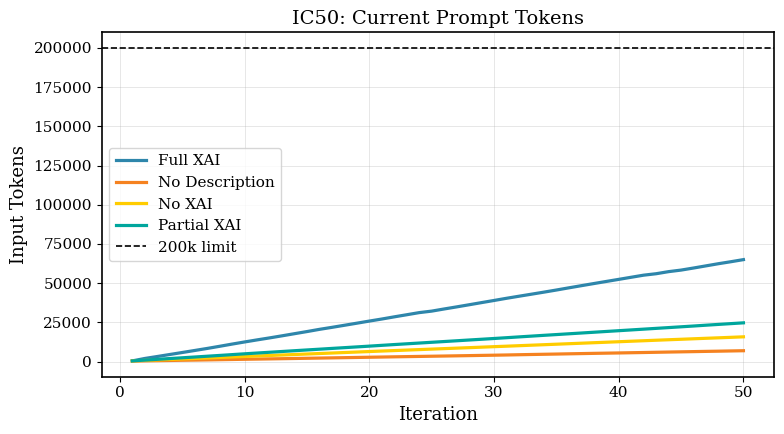

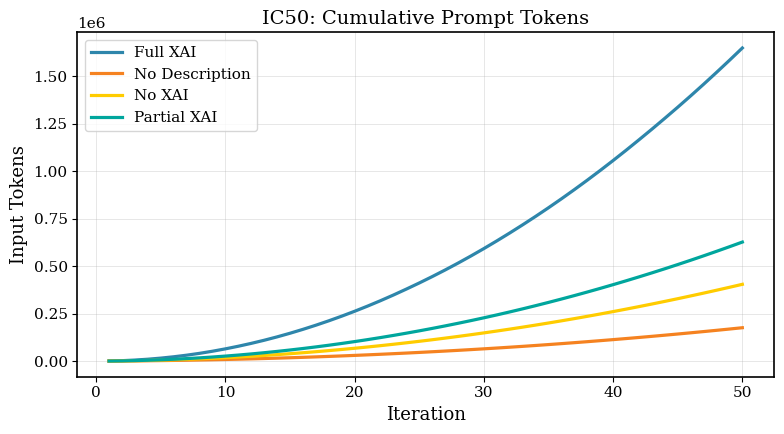


IC50 Projections:
             mode  slope_tokens_per_iteration  projected_iteration_at_200k  \
0        Full XAI                 1320.729604                   151.973478   
1     Partial XAI                  493.571269                   405.317098   
2          No XAI                  313.386699                   637.889190   
3  No Description                  134.832413                  1482.750442   

   summary_prompt_mean_tokens  
0                11733.000000  
1                 9260.000000  
2                 9075.666667  
3                 4684.333333  


In [12]:
# IC50 plotting
ic50_iter_50 = ic50_iter_df[ic50_iter_df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()
ic50_iter_mean = ic50_iter_50.groupby(["mode", "iteration"], as_index=False)[["prompt_input_tokens_current", "prompt_input_tokens_cumulative"]].mean(numeric_only=True)

for col, fname in [("prompt_input_tokens_current", "ic50_current"), ("prompt_input_tokens_cumulative", "ic50_cumulative")]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(data=ic50_iter_mean, x="iteration", y=col, hue="mode", palette=IC50_MODE_COLORS, linewidth=2.3, ax=ax)
    if col == "prompt_input_tokens_current":
        ax.axhline(CONTEXT_WINDOW_LIMIT, linestyle="--", color="black", linewidth=1.2, label="200k limit")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Input Tokens")
    ax.set_title(f"IC50: {'Current' if col == 'prompt_input_tokens_current' else 'Cumulative'} Prompt Tokens")
    ax.grid(alpha=0.35)
    ax.legend(loc="best", frameon=True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{fname}_prompt.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

ic50_projection = aggregate_and_project(ic50_iter_df, ic50_runs_df, IC50_MODE_SPECS, IC50_MODE_COLORS)
print("\nIC50 Projections:")
print(ic50_projection)

In [13]:
# IC50 costs
ic50_cost_df = compute_costs(ic50_iter_df, ic50_runs_df)
print("\nIC50 Mean Cost per Run (50 iterations + summary):")
pd.set_option("display.max_columns", None)
print(ic50_cost_df[["mode", "optimization_prompt_tokens_50", "summary_prompt_input_tokens", "optimization_total_cost_usd_est", "summary_total_cost_usd_est", "run_total_cost_usd_est"]].sort_values("mode"))


IC50 Mean Cost per Run (50 iterations + summary):
             mode  optimization_prompt_tokens_50  summary_prompt_input_tokens  \
0        Full XAI                   1.648137e+06                 11733.000000   
1  No Description                   1.757703e+05                  4684.333333   
2          No XAI                   4.042687e+05                  9075.666667   
3     Partial XAI                   6.266597e+05                  9260.000000   

   optimization_total_cost_usd_est  summary_total_cost_usd_est  \
0                         8.448583                    0.074632   
1                         0.961418                    0.038180   
2                         2.156685                    0.060628   
3                         3.273273                    0.061058   

   run_total_cost_usd_est  
0                8.523215  
1                0.999598  
2                2.217313  
3                3.334332  


In [ ]:
# IC50 compact token/cost summary table (all four modes) with 95% CI across runs

def build_ic50_summary_table(
    ic50_iter_df: pd.DataFrame,
    ic50_runs_df: pd.DataFrame,
    mode_specs: list[tuple[str, str]],
) -> pd.DataFrame:
    modes = [m for m, _ in mode_specs]

    iter_50 = ic50_iter_df[ic50_iter_df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()

    # Build per-run metrics so uncertainty can be computed across runs.
    run_grp = ["mode", "run_id", "replicate"]

    first_iter_per_run = (
        iter_50[iter_50["iteration"] == 1][run_grp + ["prompt_input_tokens_current"]]
        .rename(columns={"prompt_input_tokens_current": "initial_input_tokens"})
    )

    iter_per_run = (
        iter_50.groupby(run_grp, as_index=False)
        .agg(
            mean_input_token_increase_per_iteration=("prompt_growth_delta", "mean"),
            mean_output_tokens_per_iteration=("assistant_output_token_estimate", "mean"),
        )
    )

    summary_per_run = ic50_runs_df[
        run_grp + ["summary_prompt_input_tokens", "summary_completion_token_estimate"]
    ].rename(
        columns={
            "summary_prompt_input_tokens": "mean_input_tokens_for_summarization",
            "summary_completion_token_estimate": "mean_output_tokens_for_summarization",
        }
    )

    # Per-run projected iteration at 200k from linear fit of current prompt tokens.
    proj_rows = []
    for (mode, run_id, replicate), df_run in iter_50.groupby(run_grp):
        df_run = df_run.sort_values("iteration")
        x = df_run["iteration"].to_numpy(dtype=float)
        y = df_run["prompt_input_tokens_current"].to_numpy(dtype=float)
        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            n200k = (CONTEXT_WINDOW_LIMIT - intercept) / slope if slope > 0 else np.inf
        else:
            n200k = np.nan
        proj_rows.append(
            {
                "mode": mode,
                "run_id": run_id,
                "replicate": replicate,
                "estimated_iterations_to_200k_context": n200k,
            }
        )
    proj_per_run = pd.DataFrame(proj_rows)

    run_table = first_iter_per_run.merge(iter_per_run, on=run_grp, how="outer")
    run_table = run_table.merge(summary_per_run, on=run_grp, how="left")
    run_table = run_table.merge(proj_per_run, on=run_grp, how="left")

    # Dynamic cumulative prompt model for n iterations:
    # prompt_total(n) = sum_{k=1..n}[T1 + (k-1)*dT] = n*T1 + dT*n*(n-1)/2
    def prompt_total_tokens(n: pd.Series | float, t1: pd.Series, dt: pd.Series) -> pd.Series:
        return n * t1 + dt * (n * (n - 1) / 2.0)

    n50 = float(MAX_ITERATIONS_FOR_COST)
    prompt_total_50 = prompt_total_tokens(
        n50,
        run_table["initial_input_tokens"],
        run_table["mean_input_token_increase_per_iteration"],
    )
    completion_total_50 = n50 * run_table["mean_output_tokens_per_iteration"]

    run_table["estimated_cost_for_50_iterations"] = (
        ((prompt_total_50 + run_table["mean_input_tokens_for_summarization"]) / 1_000_000.0) * PROMPT_PRICE_PER_M
        + ((completion_total_50 + run_table["mean_output_tokens_for_summarization"]) / 1_000_000.0) * COMPLETION_PRICE_PER_M
    )

    nmax = run_table["estimated_iterations_to_200k_context"].replace([np.inf, -np.inf], np.nan)
    prompt_total_nmax = prompt_total_tokens(
        nmax,
        run_table["initial_input_tokens"],
        run_table["mean_input_token_increase_per_iteration"],
    )
    completion_total_nmax = nmax * run_table["mean_output_tokens_per_iteration"]

    run_table["estimated_cost_for_max_iteration"] = (
        ((prompt_total_nmax + run_table["mean_input_tokens_for_summarization"]) / 1_000_000.0) * PROMPT_PRICE_PER_M
        + ((completion_total_nmax + run_table["mean_output_tokens_for_summarization"]) / 1_000_000.0) * COMPLETION_PRICE_PER_M
    )

    metric_cols = [
        "initial_input_tokens",
        "mean_input_token_increase_per_iteration",
        "mean_output_tokens_per_iteration",
        "mean_input_tokens_for_summarization",
        "mean_output_tokens_for_summarization",
        "estimated_cost_for_50_iterations",
        "estimated_iterations_to_200k_context",
        "estimated_cost_for_max_iteration",
    ]

    # 95% CI half-width: 1.96 * std / sqrt(n), across runs per mode.
    agg_dict: dict[str, tuple[str, str]] = {}
    for c in metric_cols:
        agg_dict[c] = (c, "mean")
        agg_dict[f"{c}_std"] = (c, "std")
    agg_dict["n_runs"] = ("run_id", "count")

    out = run_table.groupby("mode", as_index=False).agg(**agg_dict)

    for c in metric_cols:
        out[f"{c}_ci95"] = 1.96 * (out[f"{c}_std"] / np.sqrt(out["n_runs"]))
        # If there is no deviation (or single run), CI should be 0.0.
        out[f"{c}_ci95"] = out[f"{c}_ci95"].fillna(0.0)

    # Keep all requested modes and a stable order.
    mode_frame = pd.DataFrame({"mode": modes})
    out = mode_frame.merge(out, on="mode", how="left")

    keep_cols = ["mode", "n_runs"]
    for c in metric_cols:
        keep_cols.extend([c, f"{c}_ci95"])

    out = out[keep_cols].sort_values("mode")
    return out


ic50_summary_table = build_ic50_summary_table(ic50_iter_df, ic50_runs_df, IC50_MODE_SPECS)

print("IC50 compact summary by mode (mean +/- 95% CI):")
display(ic50_summary_table)

print("\nDynamic cost(n) formula used for the estimated columns:")
print("prompt_total(n) = n * T1 + dT * n * (n - 1) / 2")
print(
    "cost(n) = ((prompt_total(n) + summary_prompt_tokens) / 1e6) * PROMPT_PRICE_PER_M "
    "+ ((n * mean_completion_tokens_per_iter + summary_completion_tokens) / 1e6) * COMPLETION_PRICE_PER_M"
)
print(f"Where n = {MAX_ITERATIONS_FOR_COST} for 'estimated_cost_for_50_iterations' and n = projected_iteration_at_200k for 'estimated_cost_for_max_iteration'.")

IC50 compact summary by mode:


,mode,initial_input_tokens,mean_input_token_increase_per_iteration,mean_output_tokens_per_iteration,mean_input_tokens_for_summarization,mean_output_tokens_for_summarization,estimated_cost_for_50_iterations,estimated_iterations_to_200k_context,estimated_cost_for_max_iteration
0,Full XAI,403.0,1318.557823,166.320000,11733.000000,638.666667,8.459448,151.973478,76.645124
3,No Description,300.0,134.714286,66.053333,4684.333333,590.333333,1.020872,1482.750442,744.651304
2,No XAI,403.0,313.387755,108.273333,9075.666667,610.000000,2.216220,637.889190,321.368614
1,Partial XAI,403.0,495.537415,111.980000,9260.000000,590.333333,3.336950,405.317098,205.029965



Dynamic cost(n) formula used for the estimated columns:
prompt_total(n) = n * T1 + dT * n * (n - 1) / 2
cost(n) = ((prompt_total(n) + summary_prompt_tokens) / 1e6) * PROMPT_PRICE_PER_M + ((n * mean_completion_tokens_per_iter + summary_completion_tokens) / 1e6) * COMPLETION_PRICE_PER_M
Where n = 50 for 'estimated_cost_for_50_iterations' and n = projected_iteration_at_200k for 'estimated_cost_for_max_iteration'.


## Boltz2 MGYP Analysis

In [18]:
boltz2_run_specs = build_boltz2_run_specs()
print(f"Boltz2 run specs: {len(boltz2_run_specs)} files")
boltz2_iter_df, boltz2_runs_df = process_run_list(boltz2_run_specs, counter)

print(f"\nBoltz2 per-iteration rows: {len(boltz2_iter_df)}")
print(f"Boltz2 runs: {len(boltz2_runs_df)}")
if not boltz2_runs_df.empty:
    mismatch = boltz2_runs_df[boltz2_runs_df["iterations_detected"] != boltz2_runs_df["iterations_reported"]]
    print(f"OK: all iterations match" if len(mismatch) == 0 else f"Mismatch: {len(mismatch)} runs")

Boltz2 run specs: 9 files

Boltz2 per-iteration rows: 0
Boltz2 runs: 0


In [19]:
# Boltz2 plotting
boltz2_iter_50 = boltz2_iter_df[boltz2_iter_df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()
boltz2_iter_mean = boltz2_iter_50.groupby(["mode", "iteration"], as_index=False)[["prompt_input_tokens_current", "prompt_input_tokens_cumulative"]].mean(numeric_only=True)

for col, fname in [("prompt_input_tokens_current", "boltz2_current"), ("prompt_input_tokens_cumulative", "boltz2_cumulative")]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(data=boltz2_iter_mean, x="iteration", y=col, hue="mode", palette=BOLTZ2_MODE_COLORS, linewidth=2.3, ax=ax)
    if col == "prompt_input_tokens_current":
        ax.axhline(CONTEXT_WINDOW_LIMIT, linestyle="--", color="black", linewidth=1.2, label="200k limit")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Input Tokens")
    ax.set_title(f"Boltz2: {'Current' if col == 'prompt_input_tokens_current' else 'Cumulative'} Prompt Tokens")
    ax.grid(alpha=0.35)
    ax.legend(loc="best", frameon=True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{fname}_prompt.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

boltz2_modes = sorted({mode for _, mode, _ in BOLTZ2_MGYP_TRACES})
boltz2_mode_specs = [(mode, mode) for mode in boltz2_modes]
boltz2_projection = aggregate_and_project(boltz2_iter_df, boltz2_runs_df, boltz2_mode_specs, BOLTZ2_MODE_COLORS)
print("\nBoltz2 Projections:")
print(boltz2_projection)

KeyError: 'iteration'

In [ ]:
# Boltz2 costs
boltz2_cost_df = compute_costs(boltz2_iter_df, boltz2_runs_df)
print("\nBoltz2 Mean Cost per Run (50 iterations + summary):")
print(boltz2_cost_df[["mode", "optimization_prompt_tokens_50", "summary_prompt_input_tokens", "optimization_total_cost_usd_est", "summary_total_cost_usd_est", "run_total_cost_usd_est"]].sort_values("mode"))


Boltz2 Mean Cost per Run (50 iterations + summary):
               mode  optimization_prompt_tokens_50  \
0    No Explanation                  372303.000000   
1        No Protein                  325693.666667   
2  With Explanation                  638167.666667   

   summary_prompt_input_tokens  optimization_total_cost_usd_est  \
0                  7249.666667                         2.006257   
1                  5868.666667                         1.743843   
2                  8046.000000                         3.356805   

   summary_total_cost_usd_est  run_total_cost_usd_est  
0                    0.051365                2.057622  
1                    0.043993                1.787837  
2                    0.054147                3.410952  


## Summary

- IC50 and Boltz2 MGYP token usage and costs have been analyzed and plotted
- All prompt token counts use Anthropic's official API when available, with tiktoken fallback
- Completion tokens are estimated from saved assistant text
- Context-limit projections show when 200k tokens will be reached based on linear growth

## Token-Efficiency Best-So-Far (Score vs Token Spend)

These plots show optimization efficiency by mode, replacing iteration/oracle calls on the x-axis with cumulative prompt tokens.
- IC50: lower is better, with QED penalty applied for QED < 0.6.
- Boltz2: higher is better (binding probability).

Full XAI: found 3 files
Partial XAI: found 3 files
No XAI: found 3 files
No Description: found 3 files


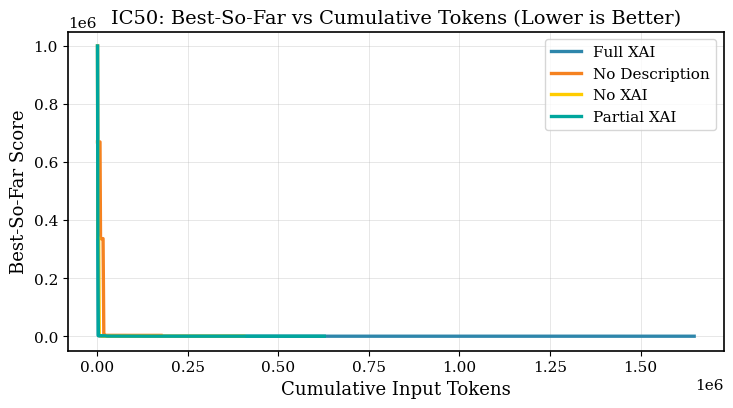

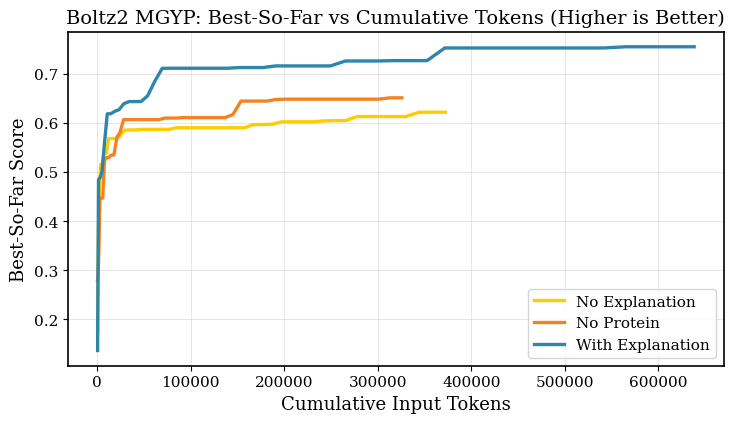

,mode,iteration,cumulative_tokens_mean,best_so_far_mean
0,Full XAI,1,403.000000,1000000.000000
1,Full XAI,2,2361.333333,2615.007528
2,Full XAI,3,5571.333333,1040.042745
3,Full XAI,4,10057.666667,799.007507
4,Full XAI,5,15818.000000,592.182638
5,Full XAI,6,22870.000000,509.318746
6,Full XAI,7,31217.666667,367.310862
7,Full XAI,8,40939.000000,306.091527
8,Full XAI,9,52070.000000,292.602091
9,Full XAI,10,64556.000000,292.602091


,mode,iteration,cumulative_tokens_mean,best_so_far_mean
0,No Explanation,1,466.000000,0.173939
1,No Explanation,2,1258.000000,0.370939
2,No Explanation,3,2361.333333,0.459926
3,No Explanation,4,3770.666667,0.515491
4,No Explanation,5,5473.000000,0.515491
5,No Explanation,6,7466.000000,0.538059
6,No Explanation,7,9751.000000,0.538059
7,No Explanation,8,12327.000000,0.568024
8,No Explanation,9,15185.333333,0.568024
9,No Explanation,10,18316.000000,0.568024


In [ ]:
def best_so_far_vs_tokens(
    df: pd.DataFrame,
    score_col: str,
    mode_colors: dict[str, str],
    title: str,
    higher_is_better: bool,
    fig_name: str,
) -> pd.DataFrame:
    work = df[df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()
    work = work.sort_values(["mode", "run_id", "iteration"])

    if higher_is_better:
        work["best_so_far"] = work.groupby(["mode", "run_id"])[score_col].cummax()
    else:
        work["best_so_far"] = work.groupby(["mode", "run_id"])[score_col].cummin()

    curve = (
        work.groupby(["mode", "iteration"], as_index=False)
        .agg(
            cumulative_tokens_mean=("prompt_input_tokens_cumulative", "mean"),
            best_so_far_mean=("best_so_far", "mean"),
        )
        .sort_values(["mode", "iteration"])
    )

    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    sns.lineplot(
        data=curve,
        x="cumulative_tokens_mean",
        y="best_so_far_mean",
        hue="mode",
        palette=mode_colors,
        linewidth=2.4,
        ax=ax,
    )
    ax.set_xlabel("Cumulative Input Tokens")
    ax.set_ylabel("Best-So-Far Score")
    ax.set_title(title)
    ax.grid(alpha=0.35)
    ax.legend(loc="best", frameon=True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / fig_name, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

    return curve


# Recompute iter/runs with updated score extraction helpers.
ic50_run_specs = build_ic50_run_specs()
ic50_iter_df, ic50_runs_df = process_run_list(ic50_run_specs, counter)
boltz2_run_specs = build_boltz2_run_specs()
boltz2_iter_df, boltz2_runs_df = process_run_list(boltz2_run_specs, counter)

# Fill missing scores before best-so-far calculation.
ic50_iter_df["trace_score_effective_ic50"] = ic50_iter_df["trace_score_effective_ic50"].fillna(QED_PENALTY_IC50)
boltz2_iter_df["trace_score_raw"] = boltz2_iter_df["trace_score_raw"].fillna(0.0)

ic50_eff_curve = best_so_far_vs_tokens(
    df=ic50_iter_df,
    score_col="trace_score_effective_ic50",
    mode_colors=IC50_MODE_COLORS,
    title="IC50: Best-So-Far vs Cumulative Tokens (Lower is Better)",
    higher_is_better=False,
    fig_name="ic50_best_so_far_vs_tokens.pdf",
)

boltz2_eff_curve = best_so_far_vs_tokens(
    df=boltz2_iter_df,
    score_col="trace_score_raw",
    mode_colors=BOLTZ2_MODE_COLORS,
    title="Boltz2 MGYP: Best-So-Far vs Cumulative Tokens (Higher is Better)",
    higher_is_better=True,
    fig_name="boltz2_best_so_far_vs_tokens.pdf",
)

display(ic50_eff_curve.head(10))
display(boltz2_eff_curve.head(10))